# Cross-Version Benchmark Leaderboards

This notebook builds leaderboards from benchmark outputs in `benchmarking/benchmarks/*/results/baseline` and `v10+`.

When present, `baseline` is the CLIP-only ablation (no caption generation, keyword search, or hybrid search).

It includes:
- Primary leaderboard (`MRR`, `Success@25`)
- Primary + Diversity leaderboard (adds `Diversity@25`)

`Success@25` is computed from the `hit` column mean.


A separate **Primary leaderboard (with ablation studies)** section includes `ablation_*` runs alongside baseline and `v10+`.


In [6]:
import sys
from pathlib import Path
from IPython.display import display

# Repo root from benchmarking/benchmarks/<BENCHMARK>/results
_repo_root = Path.cwd().parents[3]
sys.path.insert(0, str(_repo_root))

base_path = (_repo_root / "benchmarking" / "benchmarks").resolve()

from benchmarking.helpers.plot import (
    render_single_benchmark_leaderboard,
    DEFAULT_PRIMARY_WEIGHTS,
    DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS,
)

In [7]:
# Configuration
# This notebook ranks only the benchmark folder it lives in.
# Expected cwd when running this notebook: benchmarking/benchmarks/<BENCHMARK>/results
current_benchmark = Path.cwd().parents[0].name if Path.cwd().name == "results" else Path.cwd().name
min_version = 10

# Default metric weights are equal, but can be customized.
primary_metric_weights = dict(DEFAULT_PRIMARY_WEIGHTS)
primary_plus_diversity_metric_weights = dict(DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS)

print("Base path:", base_path)
print("Benchmark selected:", current_benchmark)
print("Primary weights:", primary_metric_weights)
print("Primary + Diversity weights:", primary_plus_diversity_metric_weights)

Base path: /Users/franciscolozano/Git/sage-nrp-image-search/benchmarking/benchmarks
Benchmark selected: Cloudbench
Primary weights: {'MRR': 0.5, 'Success@25': 0.5}
Primary + Diversity weights: {'MRR': 0.3333333333333333, 'Success@25': 0.3333333333333333, 'Diversity@25': 0.3333333333333333}


## Primary Leaderboard

Ranking uses weighted composite of:
- `MRR`
- `Success@25`


Cloudbench (Primary):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Cloudbench,v11,115,0.041493,0.278261,0.012870,0.091593,0.061526,0.201063,0.159877,1
1,Cloudbench,v15,115,0.065570,0.252174,0.011130,0.105275,0.052106,0.255905,0.158872,2
2,Cloudbench,v12,115,0.046615,0.269565,0.012522,0.093494,0.064458,0.202678,0.158090,3
3,Cloudbench,v13,115,0.057632,0.252174,0.011130,0.103058,0.066953,0.267524,0.154903,4
4,Cloudbench,v16,115,0.055412,0.243478,0.011130,0.095333,0.051218,0.245556,0.149445,5
5,Cloudbench,v10,115,0.029579,0.208696,0.009043,0.066930,0.047818,0.201376,0.119137,6
6,Cloudbench,v14,115,0.045178,0.191304,0.007652,0.074438,0.035297,0.250556,0.118241,7
7,Cloudbench,baseline,115,0.021332,0.121739,0.005565,0.040878,0.025862,0.112612,0.071536,8


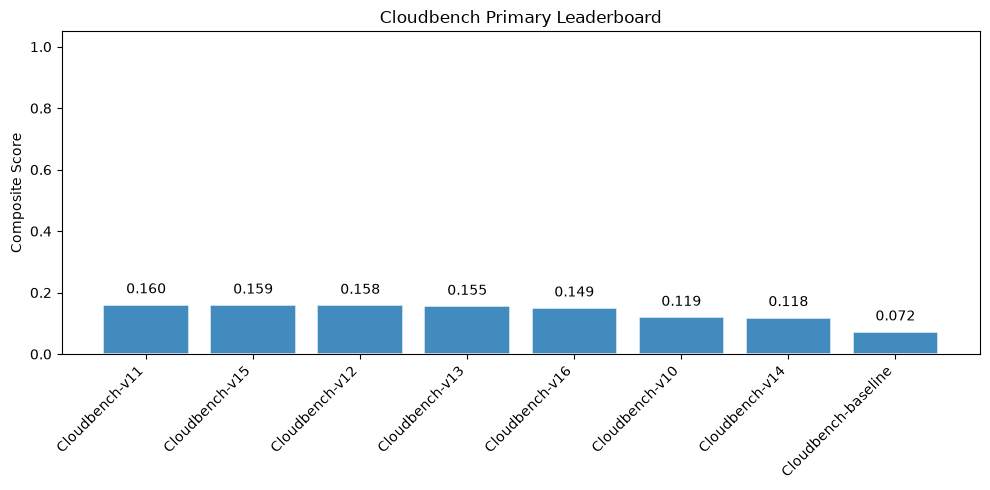

In [8]:
primary_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)

## Primary + Diversity Leaderboard

Adds `Diversity@25` to the weighted score.


Cloudbench (Primary + Diversity):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Cloudbench,v13,115,0.057632,0.252174,0.011130,0.103058,0.066953,0.267524,0.192443,1
1,Cloudbench,v15,115,0.065570,0.252174,0.011130,0.105275,0.052106,0.255905,0.191216,2
2,Cloudbench,v16,115,0.055412,0.243478,0.011130,0.095333,0.051218,0.245556,0.181482,3
3,Cloudbench,v11,115,0.041493,0.278261,0.012870,0.091593,0.061526,0.201063,0.173606,4
4,Cloudbench,v12,115,0.046615,0.269565,0.012522,0.093494,0.064458,0.202678,0.172953,5
5,Cloudbench,v14,115,0.045178,0.191304,0.007652,0.074438,0.035297,0.250556,0.162346,6
6,Cloudbench,v10,115,0.029579,0.208696,0.009043,0.066930,0.047818,0.201376,0.146550,7
7,Cloudbench,baseline,115,0.021332,0.121739,0.005565,0.040878,0.025862,0.112612,0.085228,8


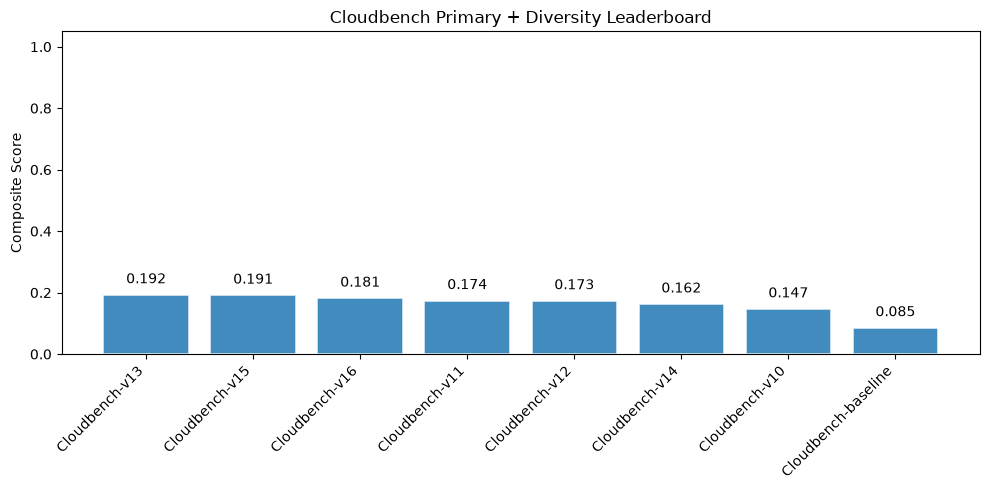

In [9]:
primary_plus_diversity_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary_plus_diversity",
    metric_weights=primary_plus_diversity_metric_weights,
    display_fn=display,
)

## Primary Leaderboard (with Ablation Studies)

Same weighted composite as the primary leaderboard (`MRR`, `Success@25`), but also includes `ablation_*` result folders when present.



Cloudbench (Primary (with Ablation Studies)):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Cloudbench,v11,115,0.041493,0.278261,0.012870,0.091593,0.061526,0.201063,0.159877,1
1,Cloudbench,v15,115,0.065570,0.252174,0.011130,0.105275,0.052106,0.255905,0.158872,2
2,Cloudbench,v12,115,0.046615,0.269565,0.012522,0.093494,0.064458,0.202678,0.158090,3
3,Cloudbench,v13,115,0.057632,0.252174,0.011130,0.103058,0.066953,0.267524,0.154903,4
4,Cloudbench,v16,115,0.055412,0.243478,0.011130,0.095333,0.051218,0.245556,0.149445,5
5,Cloudbench,ablation_cap_only,115,0.062661,0.234783,0.010435,0.099128,0.049345,0.218440,0.148722,6
6,Cloudbench,ablation_vec_only,115,0.042269,0.217391,0.010435,0.079910,0.041006,0.137431,0.129830,7
7,Cloudbench,ablation_img_only,115,0.059669,0.191304,0.008696,0.064019,0.042184,0.130437,0.125487,8
8,Cloudbench,v10,115,0.029579,0.208696,0.009043,0.066930,0.047818,0.201376,0.119137,9
9,Cloudbench,v14,115,0.045178,0.191304,0.007652,0.074438,0.035297,0.250556,0.118241,10


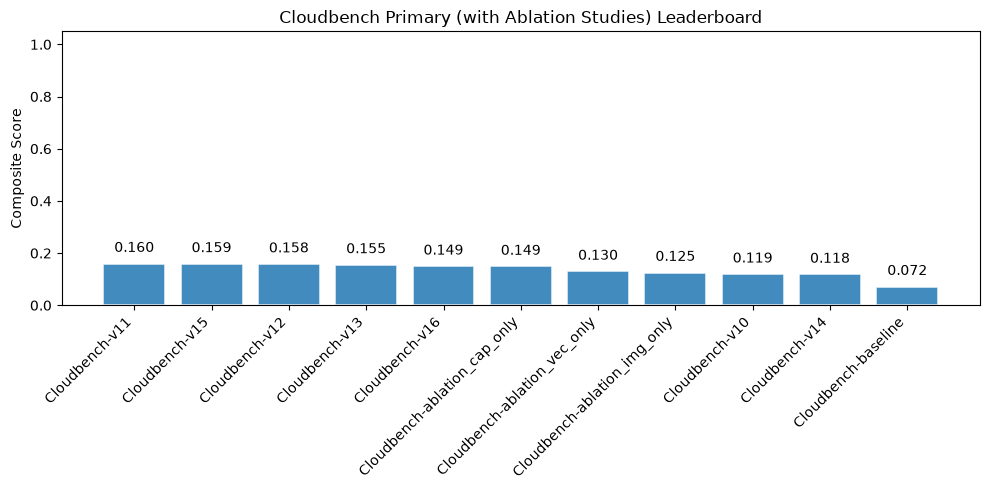

In [10]:
primary_ablation_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    include_ablations=True,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)